<a href="https://colab.research.google.com/github/ebritolbv-cmd/processamentodesinais/blob/main/iot_cnn_agroclimate_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IoT Sensor Simulation + CNN for Agroclimatic Detection

This notebook demonstrates a complete pipeline:

1. Simulation of IoT environmental sensors
2. Generation of synthetic image dataset (32x32 sensor maps)
3. Dataset labeling (normal vs thermal stress)
4. Training a Convolutional Neural Network (CNN)
5. Model evaluation

This structure is useful for research in **smart agriculture, environmental monitoring, and agroclimatic prediction**.

In [1]:
# Install required libraries (Colab usually already has them)
!pip install numpy matplotlib tensorflow scikit-learn

## Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

## Simulate IoT Sensor Matrix

Each sensor reading is converted into a **32x32 matrix**, representing a spatial map of environmental measurements.

In [3]:
def generate_sensor_matrix():
    base = np.random.normal(120, 40, (32,32))

    x = np.linspace(-1,1,32)
    y = np.linspace(-1,1,32)

    X, Y = np.meshgrid(x, y)

    pattern = np.exp(-(X**2 + Y**2)*3)*100

    sensor = base + pattern

    sensor = np.clip(sensor,0,255)

    return sensor

## Visualize a Sensor Map

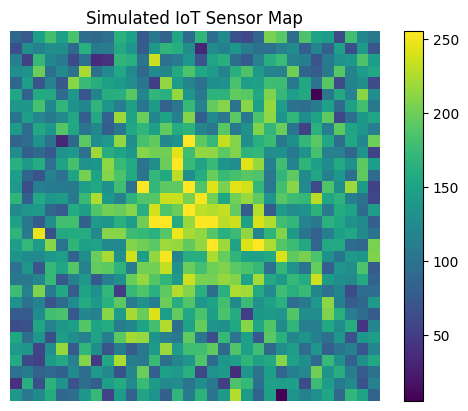

In [4]:
sample = generate_sensor_matrix()

plt.imshow(sample, cmap='viridis')
plt.colorbar()
plt.title('Simulated IoT Sensor Map')
plt.axis('off')
plt.show()

## Generate Dataset

In [5]:
images = []
labels = []

for i in range(1000):

    img = generate_sensor_matrix()

    if img.mean() > 140:
        label = 1
    else:
        label = 0

    images.append(img)
    labels.append(label)

images = np.array(images)
labels = np.array(labels)

images = images / 255.0

images = images.reshape(-1,32,32,1)

## Train/Test Split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    images,labels,test_size=0.2,random_state=42
)

## CNN Model

In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train the Model

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 1.0000 - loss: 0.0553 - val_accuracy: 0.9950 - val_loss: 0.1269
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 1.0000 - loss: 1.0248e-12 - val_accuracy: 0.9950 - val_loss: 0.1537
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 1.0000 - loss: 2.8051e-14 - val_accuracy: 0.9950 - val_loss: 0.1564
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 2.2465e-14 - val_accuracy: 0.9950 - val_loss: 0.1566
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 2.2062e-14 - val_accuracy: 0.9950 - val_loss: 0.1566
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 2.2030e-14 - val_accuracy: 0.9950 - val_loss: 0.1566
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 2.2029e-14 - val_accuracy: 0.9950 - val_loss: 0.1566
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 1.0000 - loss: 2.2029e-1

## Model Evaluation

In [9]:
loss,acc = model.evaluate(X_test,y_test)

print('Test Accuracy:', acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9950 - loss: 0.1566
Test Accuracy: 0.9950000047683716
